[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shanahdt/huji_summer_class_2026/blob/main/notebooks/day4_similarity.ipynb)

# Day 4: Melodic Similarity
**Date:** Wednesday 24 June 2026

- Today we're talking about what it means to think of music as "similar". 
- We'll build several different similarity metrics and point them at different melodies. We will then pick apart the underlying assumptions of these algorithms. 


# How do we think about musical similarity?

There isn't one agreed-upon theory of similarity in cognition: there are (at least) four,
and each one answers a different question about what we mean when we say two things are "alike":

1. **Similarity as Spatial Distance** — reduce each piece to a handful of numbers (a point in
   space) and measure how close the points are.
2. **Similarity as Feature-Set Interaction** — similarity grows with shared features and shrinks
   with distinctive ones (Tversky, 1977).
3. **Similarity as Transformation** — how many edits does it take to turn one into the other?
4. **Similarity as Alignment** — line two things up and compare their higher-order *structure*,
   not just their parts (Gentner, 1983).

![](../images/four_theories.png)

Today's we will go through all four, in roughly this order: Transformation, then Spatial
Distance (and where it breaks down), then Feature-Set Interaction (and where *that* breaks
down), then Alignment. 

| Theory | Functions |
|---|---|
| Transformation | `melodic_edit_distance()` |
| Spatial Distance | `spatial_similarity_matrix()` |
| Feature-Set Interaction | `jaccard()`, `tversky_index()` |
| Alignment | `structural_alignment()` |


# Part 1: Setting Up

In [1]:
import os
import sys

repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from pathlib import Path
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import setup_colab

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 4)

setup_colab()   # safe locally too -- only clones the course repo if it's missing


Data directory found — running locally, no clone needed.


Let's load Czech files for now, but we can adjust later.

In [19]:
from utils import load_corpus

corpus_df, streams = load_corpus('../data/Essen/Czech/')
files = [f'../data/Essen/Czech/{tune_id}.krn' 
         for tune_id in corpus_df['tune_id']]


  Loading 1/43...
Loaded 43 tunes.


# Part 2: Similarity as Transformation

One very concrete way to ask "how similar are A and B?" is: **how many edits does it take to turn
A into B?** Fewer edits, more similar.

Here's a non-musical example. What's the distance between "Dan Shanahan" and the Irish rugby
international "Dan Sheehan"?

- `Dan Shanahan` → `Dan Sh~~a~~eehan` (1 deletion)
- `Dan Shaneehan` → `Dan Sheehan` (well, plus 2 substitutions along the way)
- **Levenshtein distance = 3**

This is **edit distance** (Levenshtein distance): the minimum number of insertions, deletions,
and substitutions needed to turn one sequence into another. It generalizes to *any* sequence --
characters, note names, scale degrees -- which is exactly why it's useful for melodies. Here's a
helpful comparison of related sequence-distance algorithms, for context:

![](../images/transformation_operations.png)


### Three ways to represent a note, before comparing it

| Representation | Preserves | Ignores |
|---|---|---|
| Absolute pitches | Exact notes | Transposition |
| Scale degrees | Tonal function | Absolute pitch |
| Contour | Shape (up/down/same) | Interval size |

Edit distance doesn't care WHAT the sequence elements are, only how many edits separate two
sequences of them -- so the representation you choose changes the answer. 

## Jaccard Similarity

A different way to ask "how similar are two melodies?" is to ignore 
the order entirely and just ask: **do they share the same local patterns?** Something like n-grams, maybe?

*Jaccard similarity* compares two *sets* of n-grams:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

In non math-speak, this just means that the number of n-grams they **share**, divided by 
the total number of **unique n-grams across both**. 

- 1.0 = identical sets (every pattern in A also appears in B)  
- 0.0 = no overlap at all

For example, we could extract all trigrams from each tune, then ask what fraction of the combined pool they share.

**Interestingly,** Jaccard doesn't care where in the melody a pattern appears — only whether it appears at all. Two melodies that use the same melodic idioms in a completely different 
order could score **high on Jaccard similarity** (lots of shared 
patterns) but also **high on edit distance** (many edits needed to 
align the sequences position by position). The metrics would disagree, with  
one calling the tunes similar, the other calling them different.

In [20]:
from utils import melodic_edit_distance, ngram_similarity, contour_similarity

t1, t2 = files[0], files[1]
print(f'Tunes: {Path(t1).stem} vs {Path(t2).stem}')
print(f'Edit (norm):  {melodic_edit_distance(t1, t2, by="scale_degree"):.3f}')
print(f'Jaccard:      {ngram_similarity(t1, t2, n=3, by="scale_degree"):.3f}')
print(f'Contour:      {contour_similarity(t1, t2):.3f}')


Tunes: czech01 vs czech02
Edit (norm):  0.733
Jaccard:      0.071
Contour:      0.360


## What are these numbers telling us?

Let's look at what we just computed for `czech01` vs `czech02`:

- **Edit distance: 0.733** — these two tunes are pretty dissimilar by this measure.
  It would take edits on roughly 73% of the notes to turn one melody into the other.
  Edit distance reads the sequence left to right, so it's sensitive to notes appearing
  in different positions even if they show up in both melodies.

- **Jaccard: 0.071** — only about 7% overlap in shared trigrams. This sounds dramatic,
  but Jaccard on trigrams is actually the strictest of our three metrics — it requires
  *three consecutive notes* to match exactly. That's a high bar, and two folksongs can
  share a lot of melodic vocabulary while still arranging it differently enough to score low here.

- **Contour: 0.360** — the melodies move in the same direction (up/down/same) about
  36% of the time. This is the most generous of the three measures, and arguably the
  most musically interesting: even though the specific notes and patterns differ,
  these tunes share something about their *shape* — perhaps both rise at phrase
  beginnings, or fall at cadences.

They're answering different questions:

| Metric | The question it's asking |
|--------|--------------------------|
| Edit distance | How different are the note sequences, position by position? |
| Jaccard | Do they share the same local melodic idioms? |
| Contour | Do they move in similar ways, regardless of the specific notes? |

Which one should we trust? That depends entirely on what we're trying to do.
A musician working in an oral tradition might trust contour most — melodic shape
tends to be preserved even when specific pitches drift over time and across regions.
A search engine trying to find exact tune matches would want Jaccard's precision.

The uncomfortable conclusion: **the metric you choose determines the answer you get.**


### Edit Distance By Hand

Here are three short melodies. The second is the same as the first but with one note changed; the third changes more.

![](../images/edit_distance_grading.png)


Here  edit distance of 2 for the middle line and 12 "if only looking at pitches" for the bottom line -- a useful reminder that edit distance depends entirely on how finely you slice the comparison (note-by-note? pitch-only? rhythm too?), same as the representation choice
in the table above.


### Scaling up: a pairwise similarity matrix

One pair of tunes is a toy example. The real payoff of having a *similarity metric* is that it can be applied to large corpora. Here I've opted for 10 tunes (but we can change it!).



10 tunes selected
  1/10...


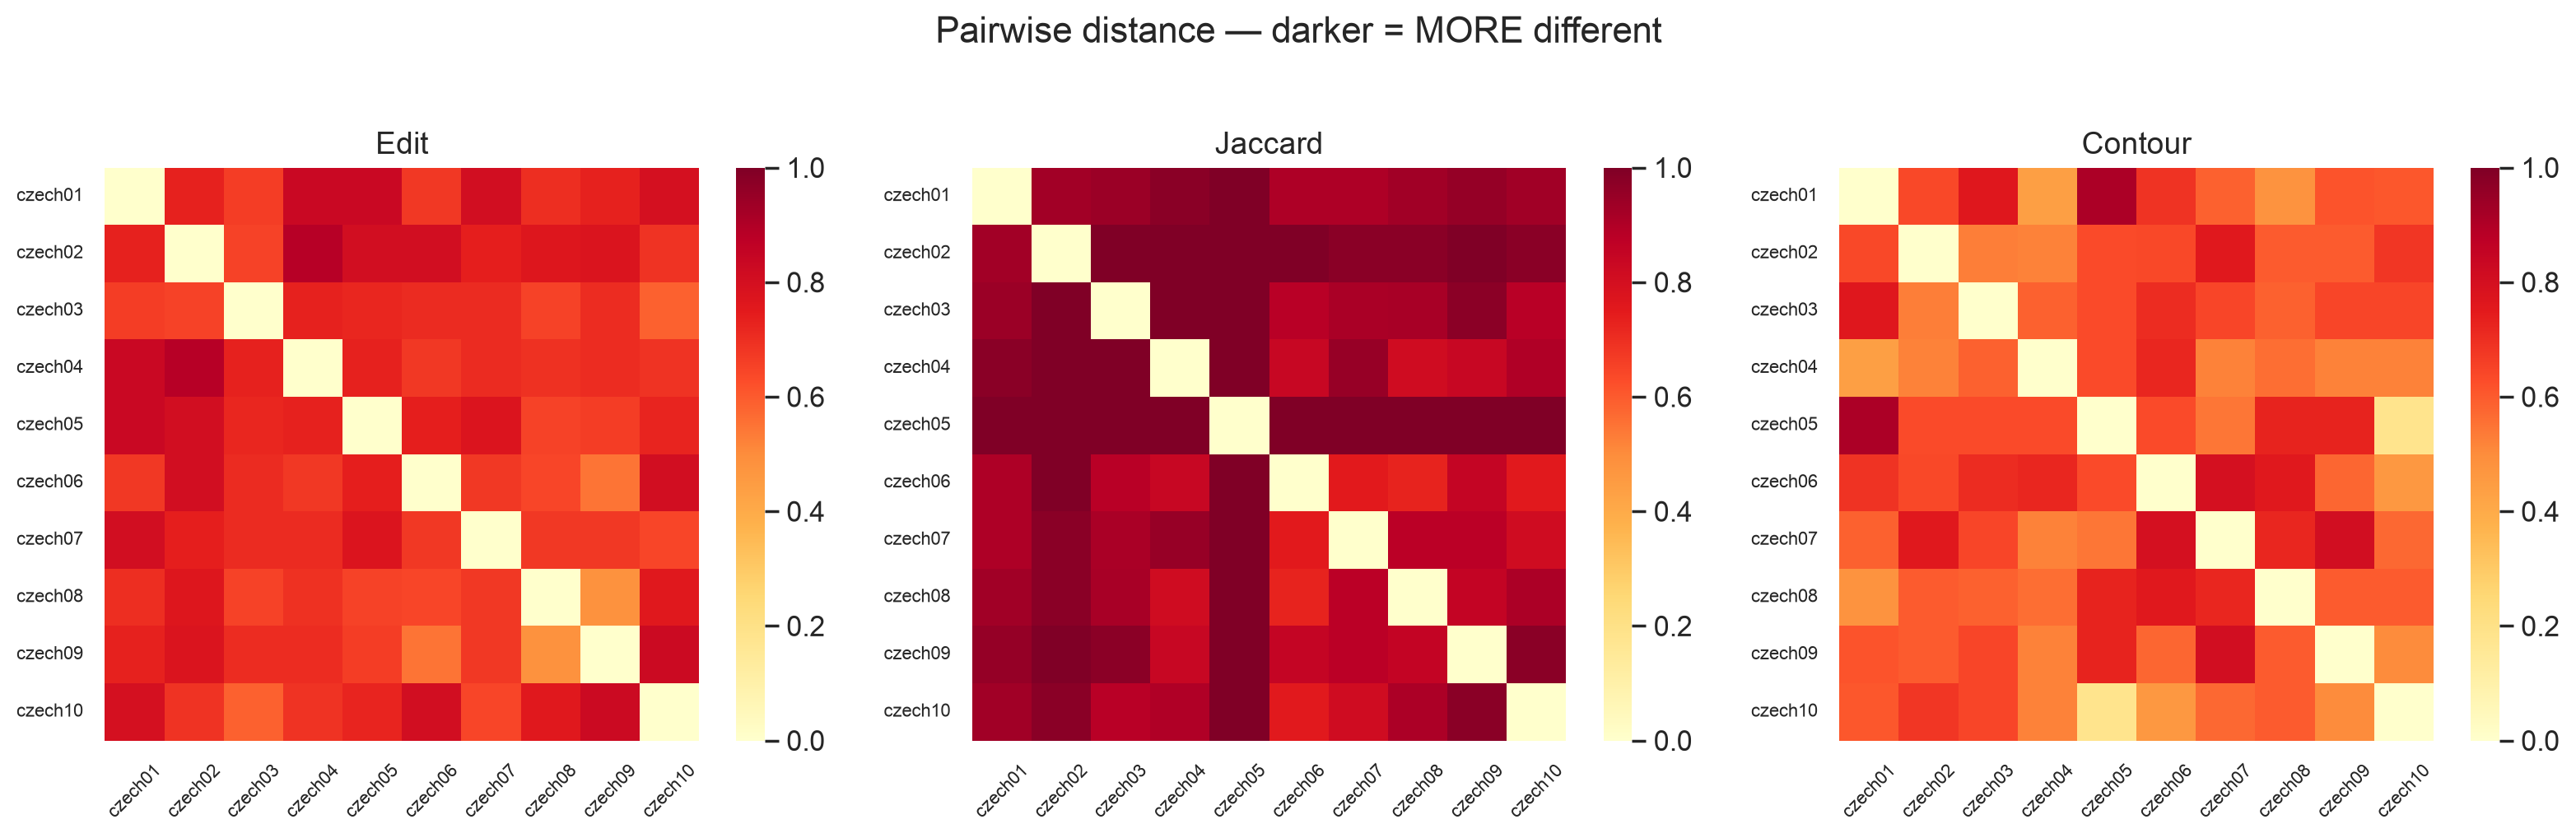

In [28]:
#### how many tunes are we interested in comparing??
N = 10
files_subset = files[:N]
print(f'{len(files_subset)} tunes selected')


### just plotting the matrices.
from utils import similarity_matrices


## note the by scale degree argument! You can also change 
## it to by='pitch' to compare by pitch directly or by="interval" 
## to compare by melodic intervals
matrices, tids = similarity_matrices(files_subset, by='scale_degree', verbose=True, plot=False)
edit_mat, jac_mat, con_mat = matrices['edit'], matrices['jaccard'], matrices['contour']

short_labels = [Path(f).stem[:8] for f in files_subset]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mat, title in zip(axes, 
                           [edit_mat, jac_mat, con_mat],
                           ['Edit', 'Jaccard', 'Contour']):
    sns.heatmap(mat, ax=ax, cmap='YlOrRd',
                xticklabels=short_labels, 
                yticklabels=short_labels,
                vmin=0, vmax=1)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Pairwise distance — darker = MORE different', y=1.02)
plt.tight_layout()
plt.show()


We can also just run this code to find the top disagreements. (you can ignore this ugly code, but run the cell...)

In [29]:
diffs = []
for i, t1 in enumerate(tids):
    for t2 in tids[i + 1:]:
        diffs.append((abs(edit_mat.loc[t1, t2] - jac_mat.loc[t1, t2]), t1, t2,
                       edit_mat.loc[t1, t2], jac_mat.loc[t1, t2]))
diffs.sort(reverse=True)

print('Top 5 metric disagreements (edit vs Jaccard):')
print(f"{'Tune A':25s} {'Tune B':25s} {'Edit':>8s} {'Jaccard':>8s} {'Diff':>7s}")
for diff, t1, t2, ed, jac in diffs[:5]:
    print(f'{t1:25s} {t2:25s} {ed:8.3f} {jac:8.3f} {diff:7.3f}')


Top 5 metric disagreements (edit vs Jaccard):
Tune A                    Tune B                        Edit  Jaccard    Diff
czech08                   czech09                      0.481    0.854   0.372
czech05                   czech08                      0.654    1.000   0.346
czech02                   czech03                      0.654    1.000   0.346
czech05                   czech09                      0.667    1.000   0.333
czech06                   czech09                      0.548    0.850   0.302


## Why does the disagreement matter?

Just to reiterate the point above about metrics, we can look at **czech02 vs czech03**: edit distance is 0.654 but Jaccard distance is 1.000. How can two tunes be moderately 
similar by one measure and completely different by another?

**Edit distance** gives partial credit. It reads the melody 
left to right and asks: how many individual notes would I need 
to change? If the same note appears in both tunes — even in 
a slightly different position — it counts toward similarity.

**Jaccard distance** gives no partial credit. It asks: do 
these tunes share any identical three-note sequences? 
If czech02 contains C-D-E somewhere and czech03 never does, 
that trigram contributes nothing to their similarity. 
Jaccard distance of 1.0 means zero shared trigrams.

Two tunes can share the same melodic vocabulary without ever producing 
the same local three-note phrase. 



Edit distance and Jaccard (n-gram overlap, via `ngram_similarity()` above) don't always agree --
the table makes that concrete. *Why* they disagree is the question the rest of this notebook is
really about: edit distance cares about ORDER, Jaccard only cares about SET MEMBERSHIP. Part 4
below makes that distinction the main event.


## Exercise: A Disagreement!

The table above shows the pairs where these measurements really disagree the most. Pick any pair of tunes in the list and run 
the cell below to see both melodies as scale degrees.

Be ready to discuss:

- What do you notice about the two sequences?
- Which metric's verdict would a musician trust more 
  for deciding whether two tunes are "similar"? Why?


In [31]:
from utils import compare_tunes
compare_tunes(tids, corpus_df, edit_mat, jac_mat, con_mat, 
              a='czech02', b='czech01', show='all')

czech02:
  scale_degrees: [1, 3, 2, 1, 2, 2, 5, 5, 1, 2, 3, 1, 6, 2, 2, 4, 4, 1, 1, 3]
  pitches: ['G4', 'B-4', 'A4', 'G4', 'A4', 'A4', 'D5', 'D5', 'G4', 'A4', 'B-4', 'G4', 'F4', 'A4', 'A4', 'C5', 'C5', 'G4', 'G4', 'B-4']
  intervals: [3, -1, -2, 2, 0, 5, 0, -7, 2, 1, -3, -2, 4, 0, 3, 0, -5, 0, 3, -1]

czech01:
  scale_degrees: [1, 1, 1, 1, 1, 4, 2, 3, 4, 5, 6, 6, 5, 4, 4, 4, 6, 1, 2, 3]
  pitches: ['G4', 'G4', 'G4', 'G4', 'G4', 'C5', 'A4', 'B4', 'C5', 'D5', 'E5', 'E5', 'D5', 'C5', 'C5', 'C5', 'F4', 'G4', 'A4', 'B4']
  intervals: [0, 0, 0, 0, 5, -3, 2, 1, 2, 2, 0, -2, -2, 0, 0, -7, 2, 2, 2, 3]

Edit distance: 0.733
Jaccard:       0.929
Contour:       0.640


### Jaccard, at the corpus level


`jaccard()` asks a different-scale question than Part 2's `ngram_similarity()`: instead of
comparing two individual TUNES, it compares two whole CORPORA via their n-gram Counters
(`|intersection| / |union|` of the top-N most common n-grams). 1.0 means two musicians' top
bigrams are identical; 0.0 means no overlap at all.

Let's zoom out from individual tunes to whole musicians -- Parker vs. Dizzy this time.


## Jaccard at the corpus level

Until now we've been comparing individual tunes to each other.
Jaccard can also work at a larger scale — comparing two whole 
*corpora* by asking how much their melodic vocabularies overlap.

Instead of comparing two sequences note by note, we pool all 
the bigrams from every tune in each corpus, take the top 50 
most common, and ask: how much do those top-50 lists overlap?

**Parker vs Dizzy: 0.639**

63.9% of the top-50 scale-degree bigrams are shared between 
Charlie Parker and Dizzy Gillespie. That's a high number — 
it tells us these two musicians are drawing from a very similar 
melodic vocabulary, which makes sense: they were both bebop 
musicians working in the same tradition, often recording together.

The matrix makes this concrete:

|        | Parker | Dizzy  |
|--------|--------|--------|
| Parker | 1.000  | 0.639  |
| Dizzy  | 0.639  | 1.000  |

The diagonal is always 1.0 — a corpus is identical to itself.
The off-diagonal tells you the overlap between the two.

**What would a low number mean?**

If we compared Parker to, say, a Czech folksong corpus, we'd 
expect a much lower Jaccard score — different traditions, 
different scales, different melodic habits. The number would 
reflect genuine stylistic distance, not just individual variation.

In [ ]:
from utils import extract_scale_degree_bigrams, jaccard, jaccard_matrix

parker_files = sorted(glob.glob('../data/charlie_parker_no_chords/*.krn'))
dizzy_files  = sorted(glob.glob('../data/dizzy_gillespie_no_chords/*.krn'))

parker_counter, _ = extract_scale_degree_bigrams(parker_files, 'Parker')
dizzy_counter, _  = extract_scale_degree_bigrams(dizzy_files, 'Dizzy')

j = jaccard(parker_counter, dizzy_counter, top_n=50)
print(f'Jaccard similarity (top 50 scale-degree bigrams): {j:.3f}')


If you have more than two musicians/corpora to compare, `jaccard_matrix()` builds the whole
pairwise table in one call -- handy for a heatmap.


In [ ]:
matrix = jaccard_matrix({'Parker': parker_counter, 'Dizzy': dizzy_counter})
matrix


# Part 3: Similarity as Spatial Distance

A completely different starting point: instead of comparing sequences directly, reduce each
piece to a handful of numbers -- a *point in space* -- then measure how close two points are.

$$sim(A, B) = \frac{1}{1 + \sqrt{\sum_{i=1}^{n}(A_i - B_i)^2}}$$

![](../images/spatial_distance.png)

Similarity is the inverse of distance, totaled across every musical dimension you chose to
measure. Here's an example that Morgan Patrick and I used for a discussed of spatial distance with four tunes by Charles Mingus. Here we plotted just two features (tonic prevalence and note density).

## Explaining the features (which are quite arbitrary, and just for demonstration!!!)

So far we've been comparing melodies directly — note by note, 
pattern by pattern. But there's another approach: instead of 
comparing the sequences themselves, we can summarise each melody 
as a small set of numbers, and then compare those numbers.

Each row in the table above is one tune, described by four features:

**`note_density`** — how many notes per beat, on average. 
A tune with lots of fast ornamental notes will score high; 
a slow, sparse melody will score low. czech01 (1.5) moves 
much faster than czech02 (0.54).

**`tonic_prevalence`** — what fraction of the notes are the 
tonic pitch (scale degree 1). A strongly tonal tune that keeps 
returning home will score high. czech04 scores very low (0.038) — 
it rarely lands on the tonic, suggesting it either avoids it 
or cadences elsewhere.

**`pitch_range`** — the span from the lowest to the highest note, 
in semitones. czech03 has a range of 14 semitones (more than an 
octave), while czech05 stays within 8 semitones — a much more 
compact melody.

**`mean_interval`** — the average size of melodic leaps in 
semitones. Higher values mean the melody tends to jump around; 
lower values mean it moves mostly by steps. czech03 (3.2) 
leaps more than czech04 (2.1).

These four numbers together place each tune at a specific 
"location" in a four-dimensional space. Two tunes that end up 
near each other in that space share similar density, tonal 
focus, range, and motion — even if their actual note sequences 
are completely different.

In [32]:
from utils import melodic_feature_vector, feature_matrix, spatial_similarity, spatial_similarity_matrix
# one tune's "point in space"
print(melodic_feature_vector(files[0]))
print()

# the same four features, for every tune in our N=20 subset
feats = feature_matrix(files_subset, tune_ids=tids)
feats.head()


note_density         1.500000
tonic_prevalence     0.100000
pitch_range         11.000000
mean_interval        2.206897
dtype: float64



,note_density,tonic_prevalence,pitch_range,mean_interval
czech01,1.500000,0.100000,11.0,2.206897
czech02,0.541667,0.307692,12.0,2.240000
czech03,1.500000,0.277778,14.0,3.235294
czech04,1.444444,0.038462,12.0,2.080000
czech05,0.600000,0.250000,8.0,2.909091


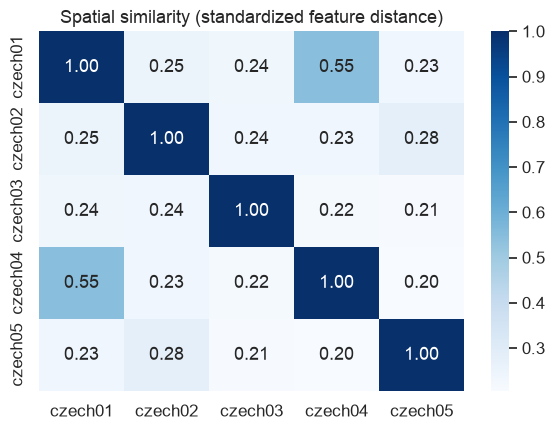

,czech01,czech02,czech03,czech04,czech05
czech01,1.000,0.253,0.238,0.546,0.233
czech02,0.253,1.000,0.236,0.234,0.279
czech03,0.238,0.236,1.000,0.220,0.211
czech04,0.546,0.234,0.220,1.000,0.205
czech05,0.233,0.279,0.211,0.205,1.000


In [ ]:
sim_spatial = spatial_similarity_matrix(feats, plot=True)
sim_spatial.round(3).iloc[:6, :6]


## How does the spatial similarity matrix get its numbers?

Each tune is reduced to _four numbers_. It turns into a point in a four-dimensional 
space. The similarity between two tunes is just how close those 
points are, converted to a [0,1] scale:

$$sim(A, B) = \frac{1}{1 + \text{distance}(A, B)}$$

Close points → small distance → score near 1.0  
Far apart → large distance → score near 0.0

**Why czech01 and czech04 score highest (0.55):**

Look at the feature table. These two tunes are the most similar 
across all four features — similar note density (~1.5 vs ~1.4), 
similar pitch range (11 vs 12 semitones), similar mean interval 
(2.2 vs 2.1). The one difference is tonic prevalence (0.10 vs 0.04) 
but that gap is small enough that the overall distance is low.

Here's the math worked out:

``czech01: note_density=1.500, tonic_prevalence=0.100, pitch_range=11.0, mean_interval=2.207``


``czech04: note_density=1.444, tonic_prevalence=0.038, pitch_range=12.0, mean_interval=2.080``


``distance = sqrt((1.500-1.444)² + (0.100-0.038)² + (11.0-12.0)² + (2.207-2.080)²)
  = sqrt(0.003 + 0.004 + 1.000 + 0.016)
  = sqrt(1.023)
  ≈ 1.011``
  
``sim = 1 / (1 + 1.011) ≈ 0.497``


**Why all scores are relatively low (0.20–0.55):**

The four features don't vary that 
dramatically (they are all Czech folksongs), so they share 
a lot of general character. The spatial model is sensitive to 
the specific numbers, so even small differences in pitch range 
or note density push tunes apart in feature space.

This is one limitation of spatial distance: in a stylistically 
homogeneous corpus, everything ends up at roughly the same distance 
from everything else, and the matrix tells you less than you'd hope.

Two features fit on a scatter plot; real feature spaces usually have more dimensions than you
can draw. The standard move is **PCA** -- project the high-dimensional feature space down to 2
axes that capture as much of the spread as possible. Here's a real example, comparing two
Renaissance composers across several melodic-motion features:

Let's do the same thing with our own 20-tune feature table.


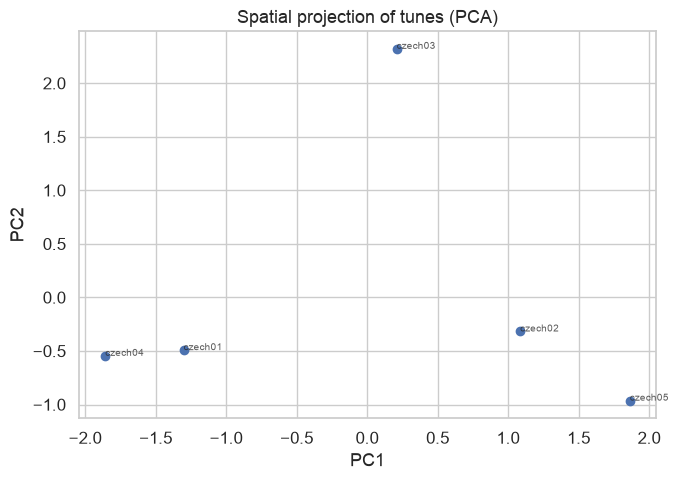

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(feats.values)
coords = PCA(n_components=2).fit_transform(scaled)

plt.figure(figsize=(7, 5))
plt.scatter(coords[:, 0], coords[:, 1])
for (x, y), tid in zip(coords, feats.index):
    plt.annotate(tid, (x, y), fontsize=7, alpha=0.75)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Spatial projection of tunes (PCA)')
plt.tight_layout()
plt.show()


![](../images/josquin.png)

### Why would spatial distance ever break down?

Picture a theme and four variations, all built from the same musical material. Spatially,
each variation can be roughly the same distance from the *theme* without being close to *each
other* at all:

![](../images/theme_and_variations.png)

That's already a hint at the cracks in this approach...

### Limitations of a spatial-distance approach

There are some limitations with this approcah, however! 

Specifically, spatial models assume three things that real similarity judgments routinely violate:

**Reflexivity** -- identical objects must have the same "address," so they should always be
judged equally similar to one another. But Krumhansl (1979) found it's *easier* to judge two
chords as identical when they're central to the key than when they're out-of-key. How
recognizable something is (think back to the classification work from Week 1) changes how
readily it's judged similar. That doesn't really fit with how spatial distance works. 

That is, where they are in space is context dependent. 

**Symmetry** -- In this approach, sim(A, B) must equal sim(B, A). 
Bartlett and Dowling (1988) found that when a
diatonic melody followed a highly chromatic one, listeners rated the pair *more* similar than
when the order was reversed. Familiarity and fluency aren't symmetric. Going from unfamiliar to
familiar is easier than the reverse, but a fixed point in space can't capture that either.

And my favorite...

**Transitivity** ("triangle inequality") -- if A is similar to B, and B is similar to C, then A
shouldn't be wildly dissimilar from C. **The classic example: Jamaica is similar to Cuba
(geographic proximity); Cuba is similar to Russia (political affinity, historically); Jamaica and
Russia are not similar at all.** 

Morgan Patrick and I discussed this in terms of Jazz tunes (as an example):

![](../images/squishy_triangle.png)

**To summarize:** spatial accounts assume reflexivity, symmetry, and transitivity, but these
assumptions are frequently at odds with how people *actually* judge similarity. 


## Let's discuss transitivity violations!

In [34]:
from utils.similarity import find_transitivity_violation


find_transitivity_violation('../data/Essen/Polska', 
                             n_tunes=30,
                             sim_threshold=0.3,   
                             diff_threshold=0.5); 

Biggest transitivity violation found:

  polska17 ~ polska22:  0.445  (similar)
  polska22 ~ polska24:  0.736  (similar)
  polska17 ~ polska24:  0.389  (not similar) ←

Violation score: 0.792

Musical question: why are polska17 and polska22 similar,
and polska22 and polska24 similar, but polska17 and polska24 are not?


# Part 4: Similarity as Feature-Set Interaction

Tversky (1977) argued similarity is perceived in terms of *discrete features*, not coordinates in a space. Perceived similarity increases with shared features and decreases with features unique to either side. Four Charles Mingus tunes, compared two different ways:

![](../images/mingus_features.png)




## Not all features count equally: salience

Tversky argued feature importance varies by **salience**, of two kinds:

- **Intensive** salience: the brightness of a light, the loudness of a tone, the saturation of a color: how strongly a feature registers on its own.

- **Diagnostic** salience:the "classificatory significance" of a feature. Features become
  more salient when they help distinguish objects from one another -- when they're more
  analytically *useful*, not just more intense.

Tversky's own experiment makes diagnostic salience concrete. Two sets of four faces:

![](../images/tversky_faces_quote.png)

25 participants grouped each set of four faces into two pairs. In Set 1, people grouped the two
*smiling* faces together, and the two non-smiling faces together. In Set 2 -- where the *frowning*
faces were the ones that visually stood out -- people grouped the frowning faces together
instead. As Tversky put it: *"smiling has a greater diagnostic value in Set 1 than in Set 2,
whereas frowning has a greater diagnostic value in Set 2 than in Set 1."*

Pushed further: *"the similarity of a (which has a neutral expression) to b (which is frowning)
should be greater in Set 1, where they are grouped together, than in Set 2, where they are
grouped separately. Likewise, the similarity of a to c (which is smiling) should be greater in
Set 2, where they are grouped together, than in Set 1, where they are not."* (Tversky, p. 342)

The faces didn't change. Only which OTHER faces they were shown alongside changed -- and that
alone flipped which features counted as diagnostic.


The same effect shows up with countries. Participants grouped Austria, Sweden, Poland, Hungary,
and Norway -- and substituting Poland for Norway in the set changed whether Sweden grouped with
Hungary or with something else entirely:

![](../images/tversky_countries.png)

Tversky's actual equation makes the "shared vs. unique features" trade-off explicit -- and adds
two independent knobs (`alpha`/`beta` below) for how much each *direction* of unique features
should count:

![](../images/tversky_equation.png)


Parts 2-3 used measures that treat "A compared to B" the same as "B compared to A" (edit
distance, Jaccard/n-gram similarity, contour, spatial distance). Tversky's index is a genuinely
different idea: it can give a *different* answer depending on which side you call "A" and which
you call "B" -- which is exactly the asymmetry the faces and countries experiments above are
demonstrating.


### Tversky's index, in code

Amos Tversky's own running example: people rate *"North Korea is similar to China"* as truer
than *"China is similar to North Korea."* The smaller, less prototypical thing gets compared *to*
the bigger one more readily than the reverse.

$$S(A, B) = \frac{|A \cap B|}{|A \cap B| + \alpha|A - B| + \beta|B - A|}$$

- `alpha = beta = 1` -> exactly Jaccard (what we just used above).
- `alpha = beta = 0.5` -> Dice's coefficient (a different but related classic measure).
- `alpha != beta` -> **asymmetric**: `tversky_index(A, B)` can give a different number than
  `tversky_index(B, A)`.

For melodies, this is useful whenever one set is the "richer" one and the other is sparser or
more skeletal -- e.g. comparing an ornamented performance against a plain version of the same
tune, where "the ornamented one resembles the plain one" and "the plain one resembles the
ornamented one" aren't really the same claim.


In [ ]:
from utils import tversky_index

# Careful: capping BOTH sides to the same top_n (as jaccard()/top_n does) forces
# |A| == |B| -- and whenever the two sets are the same size, |A-B| always equals
# |B-A| (a fixed bit of set arithmetic), so swapping A and B can never change the
# score no matter what alpha/beta you choose. To get a fair test of asymmetry, we
# instead keep each musician's bigrams that show up often enough to be a real
# habit (used >= 15 times) -- a natural threshold, not a forced equal cutoff, so
# the two sets come out different SIZES on their own.
THRESHOLD = 15
parker_set = {bg for bg, n in parker_counter.items() if n >= THRESHOLD}
dizzy_set  = {bg for bg, n in dizzy_counter.items() if n >= THRESHOLD}
print(f'Parker: {len(parker_set)} bigrams used >= {THRESHOLD}x   '
      f'Dizzy: {len(dizzy_set)} bigrams used >= {THRESHOLD}x')
print()

print('alpha=beta=1   (same as Jaccard):  ', round(tversky_index(parker_set, dizzy_set, alpha=1, beta=1), 3))
print('alpha=beta=0.5 (Dice coefficient):  ', round(tversky_index(parker_set, dizzy_set, alpha=0.5, beta=0.5), 3))
print()
print('alpha=0.1, beta=0.9 (asymmetric):')
print('  Parker -> Dizzy:', round(tversky_index(parker_set, dizzy_set, alpha=0.1, beta=0.9), 3))
print('  Dizzy -> Parker:', round(tversky_index(dizzy_set, parker_set, alpha=0.1, beta=0.9), 3))


Parker: 137 bigrams used >= 15x   Dizzy: 108 bigrams used >= 15x

alpha=beta=1   (same as Jaccard):   0.775
alpha=beta=0.5 (Dice coefficient):   0.873

alpha=0.1, beta=0.9 (asymmetric):
  Parker -> Dizzy: 0.965
  Dizzy -> Parker: 0.798


The first two lines match -- equal weights (`alpha == beta`) always give a symmetric score, no
matter how different the two sets are. Only the last pair differs, on purpose: that asymmetry is
the whole point of the index, not a bug. Parker's vocabulary turns out to be much larger than
Dizzy's at this threshold (more distinct habitual bigrams), so Dizzy contributes almost nothing
that Parker is "missing" -- but Parker contributes plenty that Dizzy is "missing." With
`beta=0.9` punishing exactly that second kind of gap heavily, "Parker resembles Dizzy" scores
higher than "Dizzy resembles Parker."

The same threshold idea scales to a full matrix -- just remember it won't be symmetric whenever
`alpha != beta`.


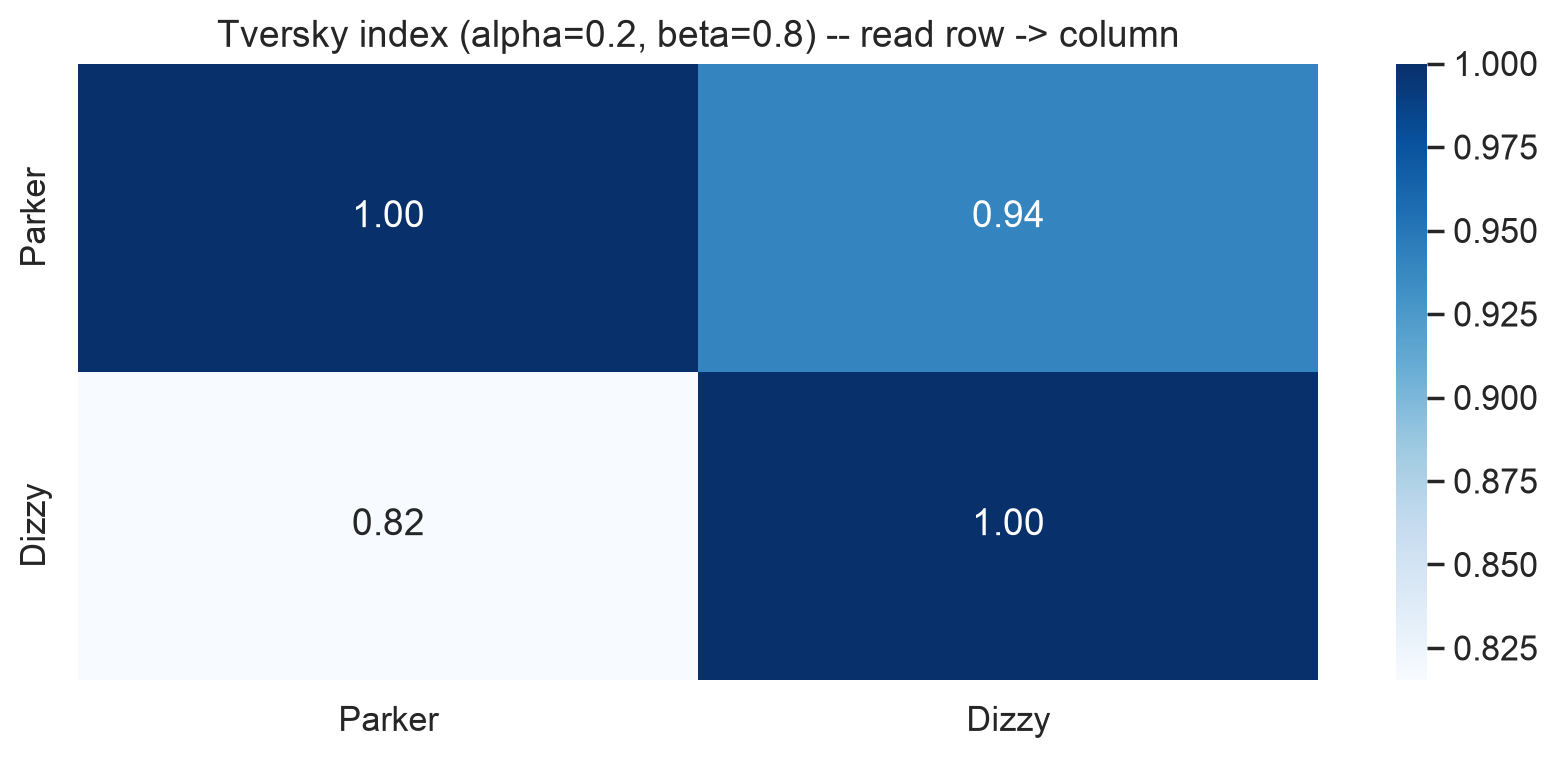

In [ ]:
tv = pd.DataFrame(
    [[tversky_index(parker_set, parker_set, 0.2, 0.8), tversky_index(parker_set, dizzy_set, 0.2, 0.8)],
     [tversky_index(dizzy_set, parker_set, 0.2, 0.8), tversky_index(dizzy_set, dizzy_set, 0.2, 0.8)]],
    index=['Parker', 'Dizzy'], columns=['Parker', 'Dizzy'],
)
sns.heatmap(tv, annot=True, fmt='.2f', cmap='Blues')
plt.title('Tversky index (alpha=0.2, beta=0.8) -- read row -> column')
plt.show()


## Reading the Tversky matrix

The matrix has four cells. Read it as **"row resembles column"**:

|        | Parker | Dizzy |
|--------|--------|-------|
| **Parker** | 1.00 | 0.94 |
| **Dizzy**  | 0.82 | 1.00 |

**Parker resembles Parker: 1.00** — a corpus is always 
identical to itself. Same for Dizzy.

**Parker resembles Dizzy: 0.94**  Parker's bigram vocabulary 
is almost entirely contained within Dizzy's. Almost everything 
Parker plays, Dizzy also plays.

**Dizzy resembles Parker: 0.82** BUT THIS IS NOT SYMMETRICAL! The reverse is weaker. Dizzy plays things that Parker doesn't. Parker's vocabulary is *larger* — he uses more distinct bigrams. 

If Parker's vocabulary is broader we might ask, "does Dizzy's vocabulary fit inside Parker's?", but it doesn't seem to be the case. There's more of Dizzy that Parker is missing.

**Why are these different?**

So "Parker resembles Dizzy" (row=Parker, col=Dizzy) is asking: 
*how much of Parker's vocabulary is missing from Dizzy?* 
The answer is: not much — 0.94.

But "Dizzy resembles Parker" is asking: *how much of Dizzy's 
vocabulary is missing from Parker?* The answer is: more — 
Dizzy plays things Parker doesn't, so the score drops to 0.82.



### Case study: melodic plagiarism

Müllensiefen and Pendzich (2009) applied a variant of Tversky's equation to model similarity in
terms of melodic interval n-grams, measuring each n-gram's salience as a function of its
frequency in a corpus of melodies (rarer n-grams counted as more salient). Melodic similarity
computed this way successfully predicted **over 90%** of real plagiarism court-case outcomes.
The winning model relied on the asymmetry assumption above: features shared with the
*plaintiff's* song mattered more than features unique to the defendant's -- exactly the kind of
directional question `alpha != beta` lets you ask.


### Case study: context changes which features matter

Lamont and Dibben (2001) played listeners excerpts from Beethoven and Schoenberg and asked them
to rate similarity between pairs. For the Beethoven piece, dynamics, texture, and articulation
mattered most for similarity judgments. For the Schoenberg piece, tempo and dynamics mattered
most instead. Their conclusion: *"the pieces set their own similarity criteria"* -- direct
support for Tversky's claim that feature importance varies with context, the same lesson the
faces and countries experiments taught above, now shown within a single piece of music rather
than across an experimental set.


### Limitations of a feature-set approach

- Feature lists are what psychologists call **unstructured representations** -- we're talking
about *which* features two things share, but not the *connections between* those features.
- Musical similarity arguably needs more than a bag of features: the temporal order, the way one
part relates to another. That's the gap Part 5 tries to fill.


---
## Part 5: Similarity as Alignment

Gentner's (1983) structure-mapping theory: similarity often comes from aligning two things and
comparing their higher-order *relations*, not just matching up isolated parts. Two jazz motives, aligned:
![](../images/alignment_example.png)

Both motives are in two halves. Both halves have an upbeat. One has exact repetition, the other varied repetition. By aligning the two motives this way, you can point at relational similarities ("each half starts the same way") that a flat feature list never represents -- and no a priori knowledge of the tunes is assumed, just the alignment itself.

The `structural_alignment()` function below is a deliberately SIMPLIFIED, illustrative version of this idea -- not a full structure-mapping engine. It splits two melodies into equal-length segments, lines them up by position, and compares each aligned pair on three relational properties: whether both segments
move in the same overall direction, whether both segments repeat their own first pitch internally, and how often their note-to-note contour agrees.


In [37]:
from utils import structural_alignment

result = structural_alignment(files[0], files[1], n_segments=2)
print(f'{Path(files[0]).stem} vs {Path(files[1]).stem}')
print(result)
print(f"\nOverall structural alignment: {result.attrs['overall_score']:.3f}")


czech01 vs czech02
   segment  direction_match  repetition_match  contour_agreement
0        1              0.0               1.0           0.250000
1        2              1.0               1.0           0.166667

Overall structural alignment: 0.569


## Reading the structural alignment output

The table above splits each tune into 2 segments and compares them 
position by position: first half against first half, second 
half against second half. Three things are measured for each 
aligned pair:

**`direction_match`** — does the overall melodic direction agree? 
Does segment 1 of czech01 go up/down/stay in the same overall 
direction as segment 1 of czech02?
- Segment 1: 0.0 — the two first halves move in opposite directions
- Segment 2: 1.0 — the two second halves move in the same direction

**`repetition_match`** — does each segment repeat its opening 
pitch internally? Both segments score 1.0 here, meaning both 
tunes have this same structural habit in both halves — they 
return to their opening note.

**`contour_agreement`** — what fraction of note-to-note movements 
agree within each aligned segment pair?
- Segment 1: 0.250 — only 25% of movements match in the first halves
- Segment 2: 0.167 — even less agreement in the second halves

**Overall structural alignment: 0.569**

This is the average across all three measures across both segments. 
A moderate score — these tunes share some structural habits 
(both return to their opening pitch) but their moment-to-moment 
contour is quite different.

**Compare this to the earlier metrics on the same pair:**

| Metric | Score | What it's asking |
|--------|-------|-----------------|
| Edit distance | 0.733 | How many note changes? |
| Jaccard | 1.000 | Any shared trigrams? |
| Contour | 0.360 | Do they move the same way? |
| Structural alignment | 0.569 | Do their halves relate the same way? |
 

That's the argument for alignment as a theory of similarity: 
two things can be structurally similar without sharing any 
surface features at all.

Compare this to Tversky's index on the same two tunes' bigrams: feature-set interaction asks "how many bigrams do these share?" with no notion of WHERE in the tune those bigrams occur. Alignment asks a structurally different question -- "does the first half of A relate to its second half the way the first half of B relates to its second half?" and can give you a very different verdict on the very same pair of tunes.


---
## Part 6: From similarity to recommendation

Every metric above answers the same underlying question -- "how alike are A and B?" -- using a
different theory of what "alike" means. A recommender system is, underneath, nothing more than
one of those similarity tables plus a rule: *"show me the closest few."* That's it. The hard part
was never the recommending -- it was picking the similarity metric, which is everything you just
spent five sections doing.

Real systems split into two families, depending on WHAT you're comparing:

- **Item-item**: "which other tunes are like this one?" -- compare items by their own features
  (exactly Parts 2-5 above).
- **User-user**: "which other listener has similar taste to this one?" -- compare listeners
  (or, here, composers standing in for listeners) to each other, then borrow from whoever's
  closest.


In [ ]:
from utils import recommend_similar


### Item-item: "more like this"

`recommend_similar()` takes one of the distance matrices you already built (edit, Jaccard,
contour) and a query tune, and returns the closest few -- exactly what a "people who streamed X
also streamed Y" feature does, minus the streaming logs.


In [ ]:
query = tids[0]
for name, matrix in [('Edit distance', edit_mat), ('Jaccard', jac_mat), ('Contour', con_mat)]:
    print(f'--- {name} ---')
    recommend_similar(matrix, tids, query, top_n=5, verbose=True)
    print()


--- Edit distance ---
Top 5 matches for 'czech01' (lower distance = more similar):
tune_id  distance
czech03  0.666667
czech02  0.733333
czech04  0.833333
czech05  0.833333
czech01       inf

--- Jaccard ---
Top 5 matches for 'czech01' (lower distance = more similar):
tune_id  distance
czech02  0.928571
czech03  0.944444
czech04  0.976744
czech05  1.000000
czech01       inf

--- Contour ---
Top 5 matches for 'czech01' (lower distance = more similar):
tune_id  distance
czech04  0.440000
czech02  0.640000
czech03  0.764706
czech05  0.909091
czech01       inf



Same query tune, three different "top 5" lists. 


### User-user: "people with similar taste"


Not sure how to implement this quickly without us taking ratings, so bear with me! Maybe we'll use composer STYLE as a stand-in.
If Bach's and Composer X's music share a style profile, a Bach fan plausibly enjoys Composer X
too?  (a stretch but again, please bear with me...)

ONLY PITCH-CLASS USAGE!

  Bach: 1/15...
Bach: 15 file(s) used, 8462 notes.
  Beethoven: 1/58...
  Beethoven: 26/58...
  Beethoven: 51/58...
Beethoven: 58 file(s) used, 195417 notes.
  Chopin: 1/49...
  Chopin: 26/49...
Chopin: skipped 1 unreadable file(s).
Chopin: 48 file(s) used, 50376 notes.
  Mozart: 1/64...
  Mozart: 26/64...
  Mozart: 51/64...
Mozart: 64 file(s) used, 89085 notes.


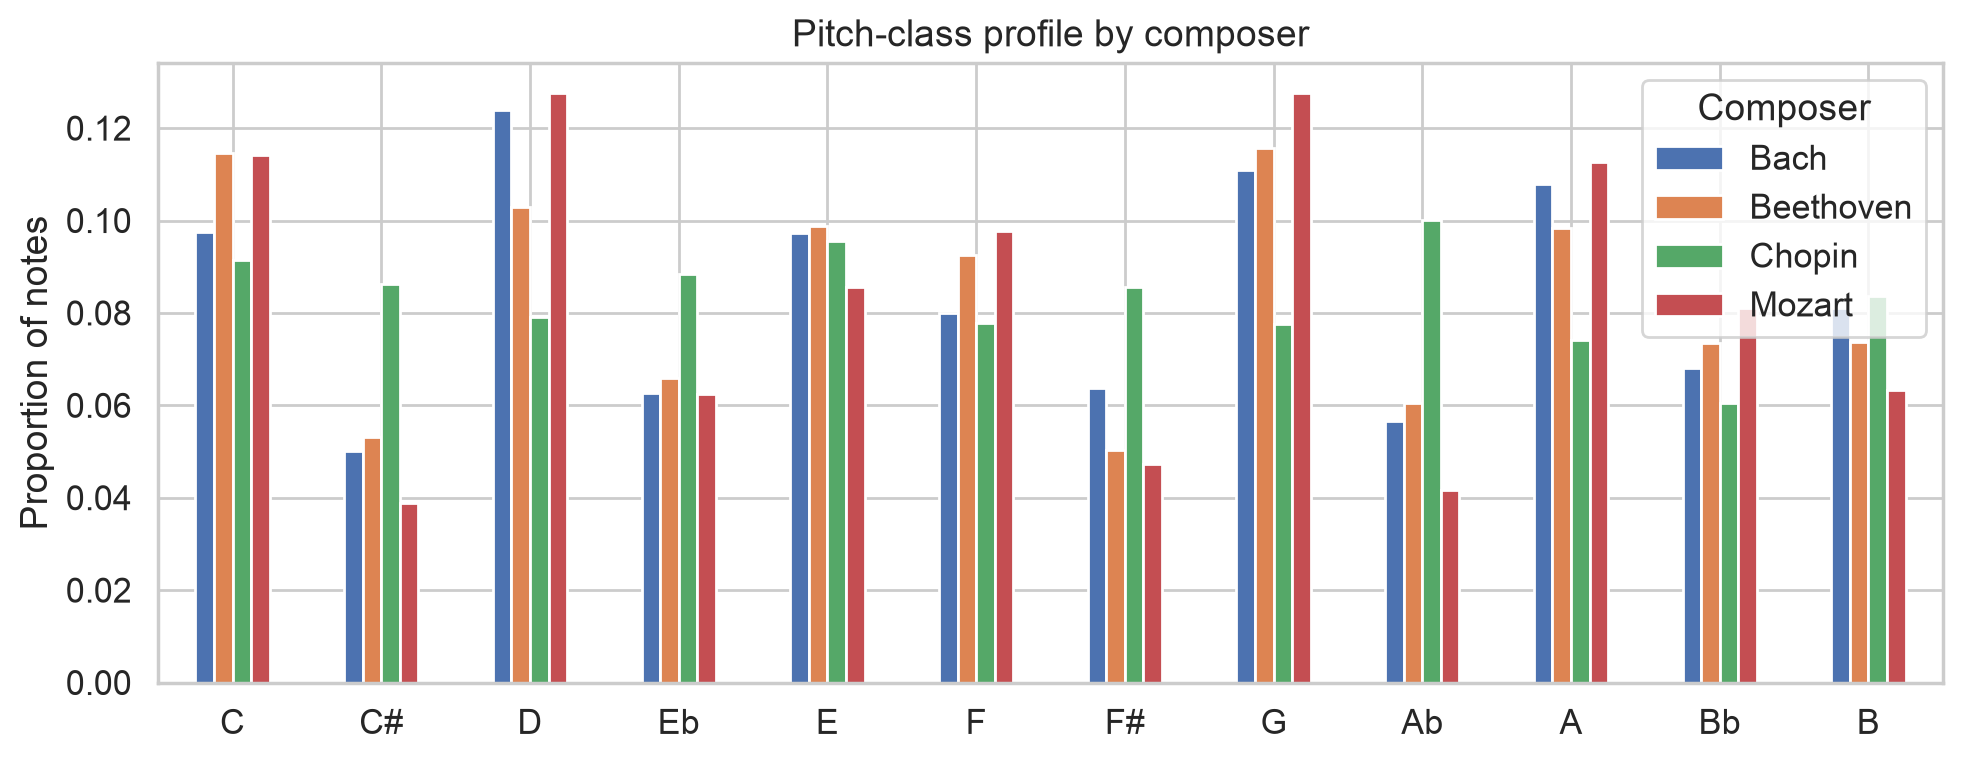

,pc_C,pc_C#,pc_D,pc_Eb,pc_E,pc_F
Bach,0.097495,0.050106,0.123966,0.062633,0.097377,0.080005
Beethoven,0.114591,0.053092,0.102831,0.065905,0.098763,0.092612
Chopin,0.091492,0.086251,0.079165,0.088435,0.095482,0.077815
Mozart,0.114082,0.038907,0.127698,0.062435,0.085671,0.097749


In [38]:
from utils import build_composer_profiles

profiles = build_composer_profiles({
    'Bach':      '../data/humdrum_scores/Bach/Inventio',
    'Beethoven': '../data/humdrum_scores/Beethoven/Quartets.Str',
    'Chopin':    '../data/humdrum_scores/Chopin/Mazurkas',
    'Mozart':    '../data/humdrum_scores/Mozart/Quartets.Str',
}, verbose=True, plot=True)

profiles.iloc[:, :6]


`composer_similarity_matrix()` turns those style profiles into a SIMILARITY matrix (higher =
more alike), unlike the DISTANCE matrices from Parts 2-3.


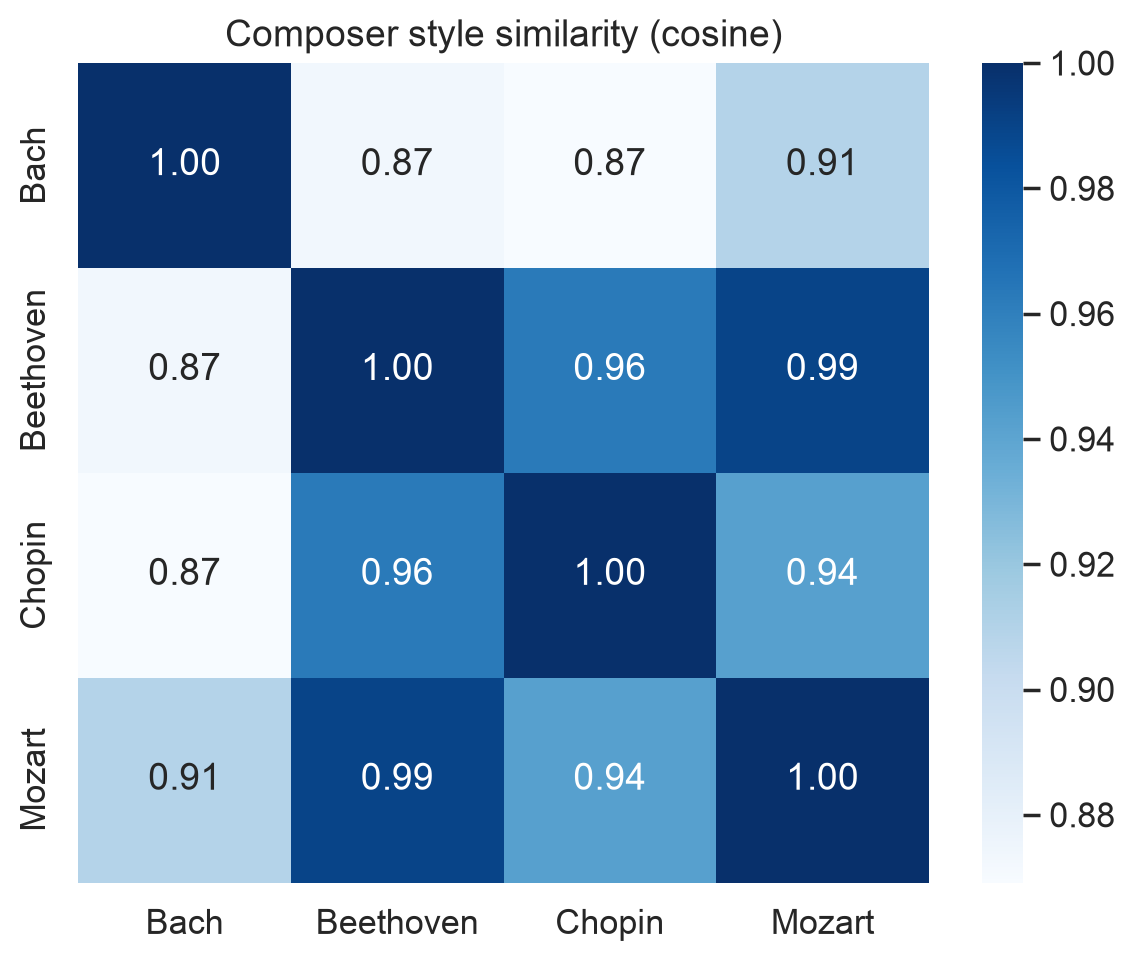

,Bach,Beethoven,Chopin,Mozart
Bach,1.000000,0.873392,0.869189,0.909116
Beethoven,0.873392,1.000000,0.962989,0.990021
Chopin,0.869189,0.962989,1.000000,0.942416
Mozart,0.909116,0.990021,0.942416,1.000000


In [42]:
from utils import composer_similarity_matrix

sim = composer_similarity_matrix(profiles, plot=True)
sim


Now the user-user payoff: pick a "listener" (here, a composer) and ask who else has the most
similar overall taste/style.


In [43]:
from utils import user_user_recommend

user_user_recommend('Beethoven', sim, top_n=3, verbose=True)


If 'Beethoven' were a listener, based on overall style, they'd most likely enjoy:
  Mozart: similarity = 0.990
  Chopin: similarity = 0.963
  Bach: similarity = 0.873


Mozart    0.990021
Chopin    0.962989
Bach      0.873392
Name: Beethoven, dtype: float64

If 'Bach' were a listener, this is the "you might also like" list -- built from style similarity
rather than play-count co-occurrence, but structurally the exact same move: a similarity matrix,
plus "show me the closest few."


In [40]:
from utils import recommender_widget

recommender_widget({'Edit distance': edit_mat, 'Jaccard': jac_mat, 'Contour': con_mat}, tids)


Output()

---
## Wrapping up: five lenses, one question

"How similar are A and B?" sounds like it should have one answer. Today gave you five different
ones, each built on a different theory of what similarity even is:

| Theory | Question it asks | `utils` function |
|---|---|---|
| Transformation | How many edits turn A into B? | `melodic_edit_distance()` |
| Spatial Distance | How close are A and B as points in feature-space? | `spatial_similarity_matrix()` |
| Feature-Set Interaction | How many features do A and B share vs. not share? | `jaccard()`, `tversky_index()` |
| Alignment | Does A's internal structure correspond to B's? | `structural_alignment()` |
| (bonus) Contour | Does A's up/down shape match B's? | `contour_similarity()` |

None of these is "correct" -- each one is blind to something the others can see, which is exactly
why the Part 2 "metric disagreement" table had real disagreements in it. And Part 6 showed why
this isn't just an academic distinction: every recommender system you've ever used made one of
these choices for you, invisibly, before it ever showed you a "you might also like."


## In-class exercise: Discussing disagreement

Pick a tune ID from `tids` you haven't looked at yet. Using `edit_mat`, `jac_mat`, and `con_mat`,
find its single closest match under each of the three metrics.

- Do all three metrics agree on the closest match?
- If not, look at the two tunes by hand (try `note_sequence()` or `pitch_class_sequence()` on
  each) -- can you tell *why* the metrics disagree, in terms of which theory of similarity each
  one is built on?


In [ ]:
query = tids[2]
print('Edit:   ', recommend_similar(edit_mat, tids, query, top_n=1))
print('Jaccard:', recommend_similar(jac_mat, tids, query, top_n=1))
print('Contour:', recommend_similar(con_mat, tids, query, top_n=1))


Edit:       tune_id  distance
0  czech02  0.653846
Jaccard:    tune_id  distance
0  czech01  0.944444
Contour:    tune_id  distance
0  czech02  0.529412


---
## Project Log — Entry 4

Add an entry to your project log reflecting on today's material as it relates to your own
project corpus:

1. Which of the five similarity theories above (transformation, spatial distance, feature-set
   interaction, alignment, or contour) seems most appropriate for the musical question your
   project is asking? Why?
2. Run at least one of today's `utils` functions against your own corpus. What did you learn?
3. If you were to build a "more like this" recommender for your corpus, would item-item or
   user-user make more sense -- and what would stand in for "user" if you don't have listening
   logs?
